In [1]:
import sys
sys.path.append('../')
from fluProfiler_models import fluProfiler
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
from utilities import load_embedding
from torch.utils.data import Dataset, DataLoader
from utilities import print_exams
import matplotlib.pyplot as plt

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result
 
def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

In [2]:
Crick_data = pd.read_csv('../../data/reverse_test/processed/All.csv')

In [3]:
device = torch.device('cuda:1')
columns = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d', 'seq_a', 'seq_b', 'seq_c', 'seq_d', 
           'serumPassCat', 'virusPassCat', 'serumName', 'virusName', 'serumDate', 'virusDate', 
           'Type', 'serumIslID', 'virusIslID', 'label']
Crick_early = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] <= '40', columns]

Crick_2024NH = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '41', columns]
Crick_2024SH = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '42', columns]
Crick_2025NH = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '43', columns]
Crick_2025SH = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '44', columns]

## 1. Vaccine recommendation for 2025 NH

In [4]:
## serum selection
candidate_df = pd.concat([Crick_early, Crick_2024NH])
groupby_columns = ['seq_a', 'seq_b', 'serumPassCat']
agg_dict = {'seq_id_a': 'first', 'seq_id_b': 'first', 'label': 'mean', 'serumName': 'first', 'serumIslID': 'first'}
H1_serum = candidate_df.loc[candidate_df['Type'] == 'H1N1'].groupby(groupby_columns).agg(agg_dict).reset_index()
H3_serum = candidate_df.loc[candidate_df['Type'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()
## virus selection
groupby_columns = ['seq_c', 'seq_d', 'virusPassCat']
agg_dict = {'seq_id_c': 'first', 'seq_id_d': 'first', 'label': 'mean', 'virusName': 'first', 'virusIslID': 'first'}
H1_virus = Crick_2024NH.loc[Crick_2024NH['Type'] == 'H1N1'].groupby(groupby_columns).agg(agg_dict).reset_index()
H3_virus = Crick_2024NH.loc[Crick_2024NH['Type'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()

In [5]:
seq_names = pd.concat([H3_serum['seq_id_a'], H3_serum['seq_id_b'], H3_virus['seq_id_c'], H3_virus['seq_id_d']]).unique().tolist()
file_names = ['matrix_' + ID + '.pt' for ID in seq_names]
emb_dict = load_embedding('../../data/reverse_test/embedding', files=file_names, map_location=device)

Loading tensor: 100%|██████████| 458/458 [00:17<00:00, 26.42file/s]


In [6]:
test_df = H3_serum.merge(H3_virus, how='cross')
test_df['label'] = 0
test_dataset = fluProfiler_Dataset(test_df)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [7]:
model = torch.load('/home/chenyh/workspace/fluProfiler/src/Section1_Antigenic_space/4_Reverse_test/model_4_2024NH/model/2026-02-03_03-35-22.pth', weights_only=False, map_location=device)
prediction_ls_test = []
reference_ls_test = []
logits_ls = []
loss_ls_test = []
model.eval()
for batch in test_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch

    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])

    # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c,
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b,
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats,
                                        labels=labels)

    loss_ls_test.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls_test.extend(output.view(-1).tolist())
    reference_ls_test.extend(labels.tolist())

test_mae, test_mse, test_pearson, test_spearman, test_R2 = print_exams(reference_ls_test, prediction_ls_test, print_result=False)
test_df['prediction'] = prediction_ls_test

/home/chenyh/workspace/fluProfiler/src/Section3_Vaccine_recommendation/../utilities.py:72: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  MAE, MSE, Pearson, Spearman, R2 = mean_absolute_error(O, P), mean_squared_error(O, P), pearsonr(O, P), spearmanr(O, P), r2_score(O, P)


In [8]:
vaccine = test_df.groupby(['seq_a', 'seq_b', 'serumPassCat']).agg({'prediction': 'mean', 'serumName': 'first', 'serumIslID': 'first'}).reset_index()
vaccine['vaccine'] = vaccine['serumName'] + ' ' + vaccine['serumPassCat'].str.replace('<', '').str.replace('>', '')
vaccine['prediction'] = vaccine['prediction'] * -1
vaccine = vaccine.sort_values(by='prediction', ascending=False)
vaccine.to_csv('2024NH_vaccine.csv', index=False)

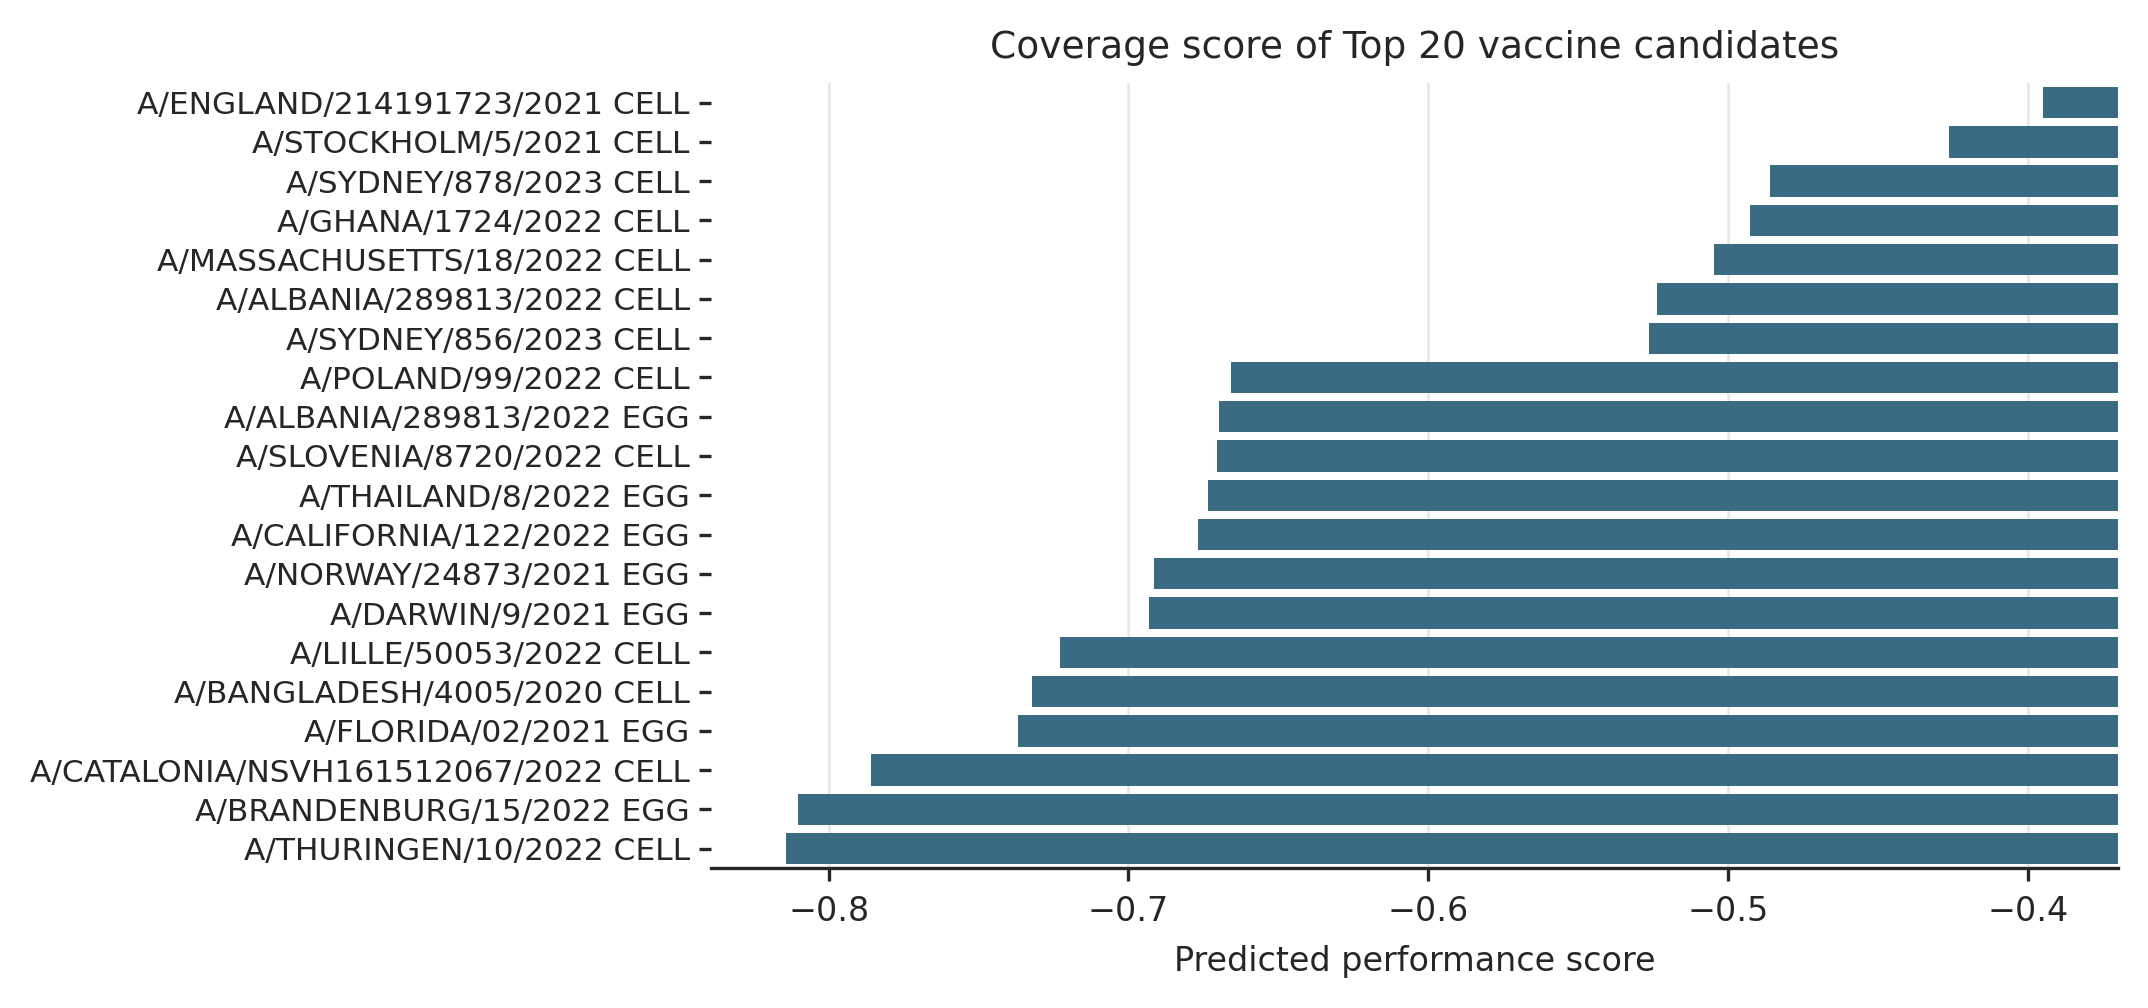

In [9]:
# 1) 全局风格：偏 Nature 的 paper 风格（克制、细线、无花哨）
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "figure.dpi": 300
})

# 2) 数据：按 prediction 排序后取 Top20（你原逻辑）
top20 = vaccine.sort_values("prediction", ascending=False) \
    .drop_duplicates(subset=["vaccine"], keep="first").head(20).copy()

# 精简标签
top20["vaccine_label"] = top20["vaccine"].str.replace(r"^A/","", regex=True) \
                                       .str.replace(" EGG"," (EGG)")\
                                       .str.replace(" CELL"," (CELL)")
ycol = "vaccine_label"
# ycol = "vaccine"

# 3) 画图：更紧凑的横向条形图 + 0 参考线 + 轻网格
fig, ax = plt.subplots(figsize=(7.2, 3.4))  # Nature 常用更紧凑比例；你也可微调

bar_color = "#2E6F8E"  # 低饱和蓝绿，比纯绿更“期刊”

sns.barplot(
    data=top20,
    y=ycol,
    x="prediction",
    color=bar_color,
    edgecolor="none",   # 取消边缘描边，避免脏
    ax=ax
)

# 0 参考线：你这个分布特别需要
ax.axvline(0, color="0.2", lw=0.8)

# 轻网格：只保留 x 方向，且非常淡
ax.xaxis.grid(True, which="major", color="0.9", lw=0.6)
ax.yaxis.grid(False)

# 去掉多余脊线：保留左/下或只保留下（按你偏好）
sns.despine(ax=ax, left=True, bottom=False)

ax.set_xlabel("Predicted performance score")
ax.set_ylabel("")
ax.set_title("Coverage score of Top 20 vaccine candidates", pad=6)

# 让 y 标签更整齐：减少与图形的“挤压”
ax.tick_params(axis="y", pad=2)

# 控制 x 轴范围（可选）：给正端留一点空白，避免贴边
xmin = top20["prediction"].min()
xmax = top20["prediction"].max()
pad = (xmax - xmin) * 0.06 if xmax > xmin else 0.1
ax.set_xlim(xmin - pad, xmax + pad)

who = "A/THAILAND/08/2022 EGG"
labels = []
for name in top20["vaccine"]:
    labels.append(("★ " + name) if name in who else name)
ax.set_yticklabels(labels)

fig.tight_layout()
plt.show()
# plt.savefig('2024NH_vaccine.svg', transparent=True)

## 2. Vaccine recommendation for 2025 SH

In [14]:
## serum selection
candidate_df = pd.concat([Crick_early, Crick_2024NH, Crick_2024SH])
groupby_columns = ['seq_a', 'seq_b', 'serumPassCat']
agg_dict = {'seq_id_a': 'first', 'seq_id_b': 'first', 'label': 'mean', 'serumName': 'first', 'serumIslID': 'first'}
H1_serum = candidate_df.loc[candidate_df['Type'] == 'H1N1'].groupby(groupby_columns).agg(agg_dict).reset_index()
H3_serum = candidate_df.loc[candidate_df['Type'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()
## virus selection
groupby_columns = ['seq_c', 'seq_d', 'virusPassCat']
agg_dict = {'seq_id_c': 'first', 'seq_id_d': 'first', 'label': 'mean', 'virusName': 'first', 'virusIslID': 'first'}
H1_virus = Crick_2024SH.loc[Crick_2024SH['Type'] == 'H1N1'].groupby(groupby_columns).agg(agg_dict).reset_index()
H3_virus = Crick_2024SH.loc[Crick_2024SH['Type'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()

In [15]:
seq_names = pd.concat([H3_serum['seq_id_a'], H3_serum['seq_id_b'], H3_virus['seq_id_c'], H3_virus['seq_id_d']]).unique().tolist()
file_names = ['matrix_' + ID + '.pt' for ID in seq_names]

file_names_early = []
file_names_2024NH = []
file_names_2024SH = []
for f in file_names:
    if '_2024NH' in f:
        file_names_2024NH.append(f.replace('_2024NH', ''))
    elif '_2024SH' in f:
        file_names_2024SH.append(f.replace('_2024SH', ''))
    else:
        file_names_early.append(f)

In [16]:
emb_dict_early = load_embedding('../../data/data_40/embedding_Crick', files=file_names_early, map_location=device)
emb_dict_2024NH = load_embedding('../../data/data_40/embedding_vac_41',files=file_names_2024NH,map_location=device)
emb_dict_2024SH = load_embedding('../../data/data_40/embedding_vac_42',files=file_names_2024SH,map_location=device)
emb_dict_2024NH = {key + '_2024NH': value for key, value in emb_dict_2024NH.items()}
emb_dict_2024SH = {key + '_2024SH': value for key, value in emb_dict_2024SH.items()}

emb_dict = emb_dict_early | emb_dict_2024NH | emb_dict_2024SH

Loading tensor: 100%|██████████| 634/634 [01:47<00:00,  5.90file/s]


In [17]:
test_df = H3_serum.merge(H3_virus, how='cross')
test_df['label'] = 0
test_dataset = fluProfiler_Dataset(test_df)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [30]:
model = torch.load('../../trained_model/Vaccine_model/model_to_2024NH/2025-11-19_02-18-01.pth', weights_only=False, map_location=device)
prediction_ls_test = []
reference_ls_test = []
logits_ls = []
loss_ls_test = []
model.eval()
for batch in test_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch

    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c,
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b,
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats,
                                        labels=labels)

    loss_ls_test.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls_test.extend(output.view(-1).tolist())
    reference_ls_test.extend(labels.tolist())

test_mae, test_mse, test_pearson, test_spearman, test_R2 = print_exams(reference_ls_test, prediction_ls_test, print_result=False)
test_df['prediction'] = prediction_ls_test

/mnt/zzbnew/peixunban/chenyihao/fluProfiler/src/Section3_Vaccine_recommendation/../utilities.py:72: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  MAE, MSE, Pearson, Spearman, R2 = mean_absolute_error(O, P), mean_squared_error(O, P), pearsonr(O, P), spearmanr(O, P), r2_score(O, P)


In [32]:
vaccine = test_df.groupby(['seq_a', 'seq_b', 'serumPassCat']).agg({'prediction': 'mean', 'serumName': 'first', 'serumIslID': 'first'}).reset_index()
vaccine['vaccine'] = vaccine['serumName'] + ' ' + vaccine['serumPassCat'].str.replace('<', '').str.replace('>', '')
vaccine['prediction'] = vaccine['prediction'] * -1
vaccine = vaccine.sort_values(by='prediction', ascending=False)
vaccine.to_csv('2024SH_vaccine.csv', index=False)

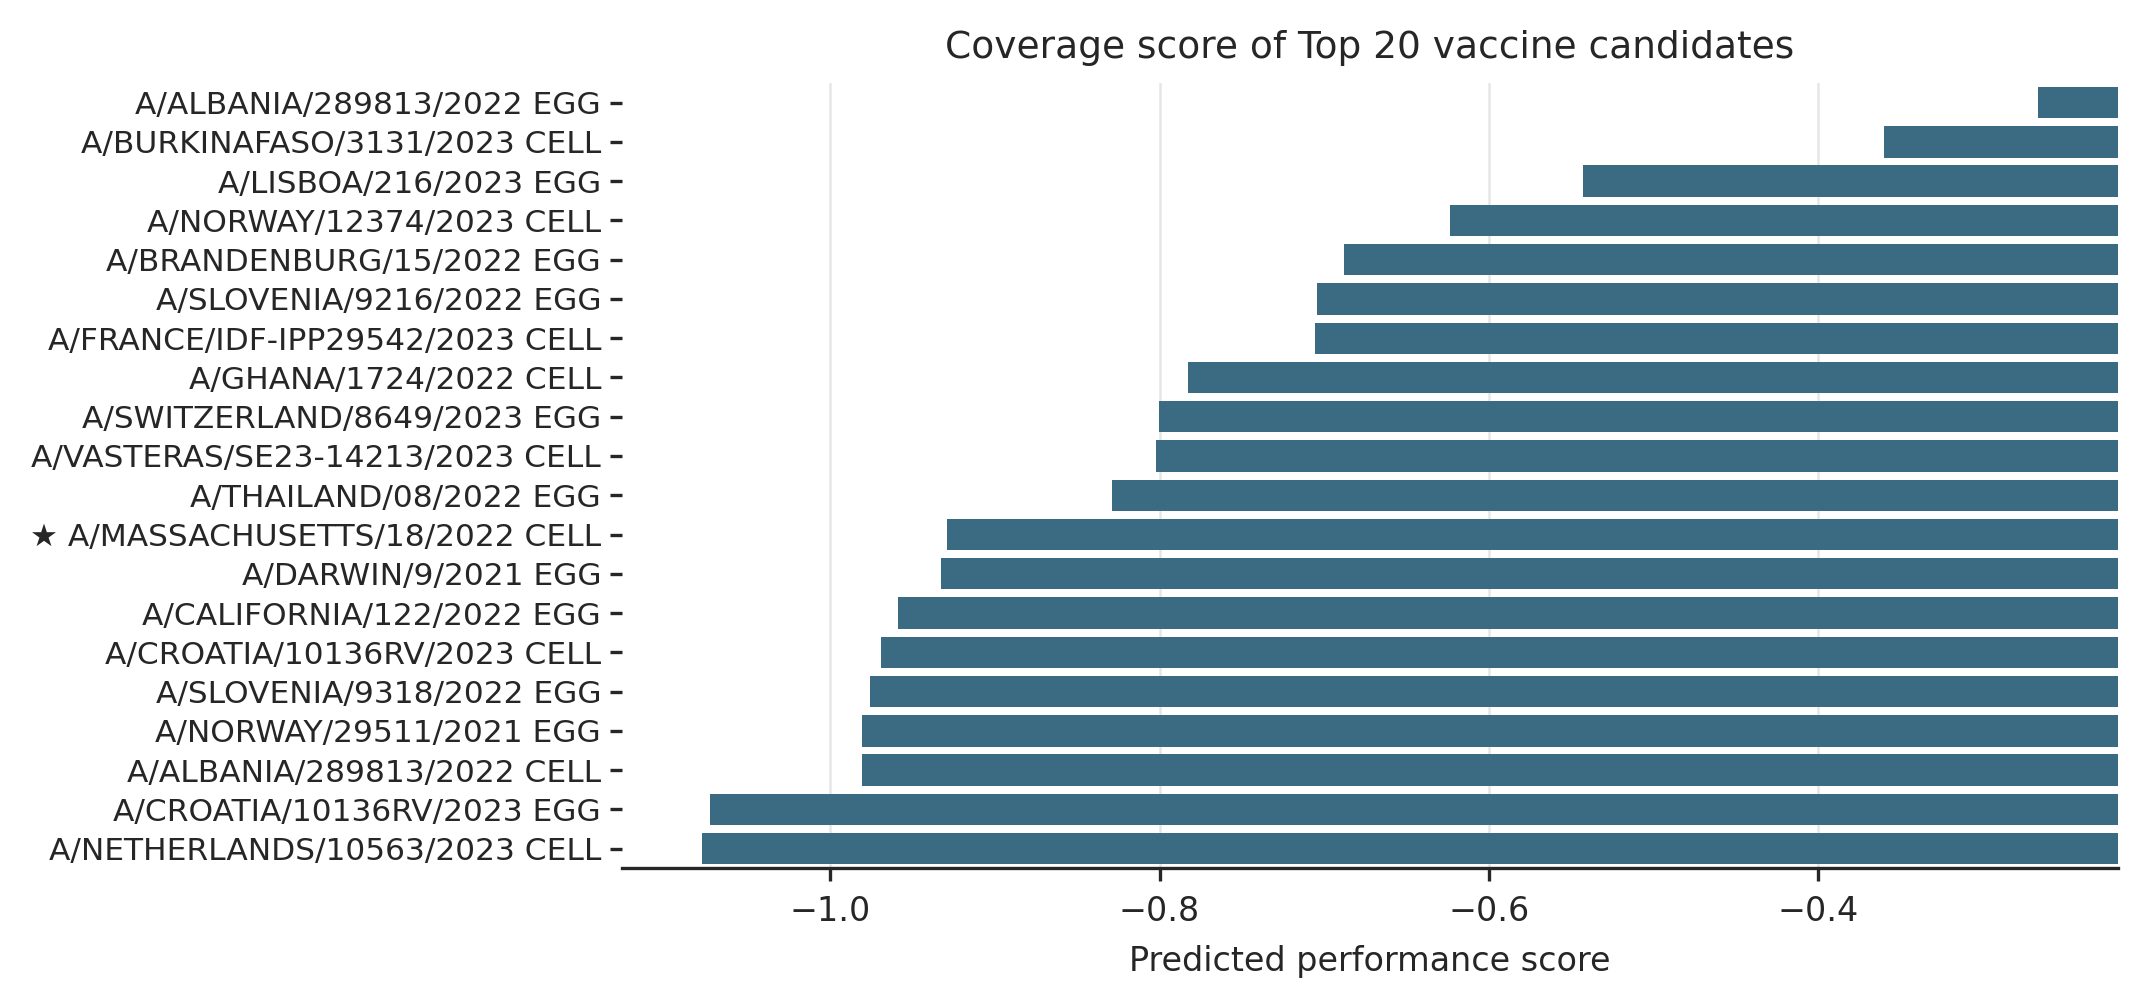

In [33]:
# 1) 全局风格：偏 Nature 的 paper 风格（克制、细线、无花哨）
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "figure.dpi": 300
})

# 2) 数据：按 prediction 排序后取 Top20（你原逻辑）
top20 = vaccine.sort_values("prediction", ascending=False) \
    .drop_duplicates(subset=["vaccine"], keep="first").head(20).copy()

# 精简标签
top20["vaccine_label"] = top20["vaccine"].str.replace(r"^A/","", regex=True) \
                                       .str.replace(" EGG"," (EGG)")\
                                       .str.replace(" CELL"," (CELL)")
ycol = "vaccine_label"
# ycol = "vaccine"

# 3) 画图：更紧凑的横向条形图 + 0 参考线 + 轻网格
fig, ax = plt.subplots(figsize=(7.2, 3.4))  # Nature 常用更紧凑比例；你也可微调

bar_color = "#2E6F8E"  # 低饱和蓝绿，比纯绿更“期刊”

sns.barplot(
    data=top20,
    y=ycol,
    x="prediction",
    color=bar_color,
    edgecolor="none",   # 取消边缘描边，避免脏
    ax=ax
)

# 0 参考线：你这个分布特别需要
ax.axvline(0, color="0.2", lw=0.8)

# 轻网格：只保留 x 方向，且非常淡
ax.xaxis.grid(True, which="major", color="0.9", lw=0.6)
ax.yaxis.grid(False)

# 去掉多余脊线：保留左/下或只保留下（按你偏好）
sns.despine(ax=ax, left=True, bottom=False)

ax.set_xlabel("Predicted performance score")
ax.set_ylabel("")
ax.set_title("Coverage score of Top 20 vaccine candidates", pad=6)

# 让 y 标签更整齐：减少与图形的“挤压”
ax.tick_params(axis="y", pad=2)

# 控制 x 轴范围（可选）：给正端留一点空白，避免贴边
xmin = top20["prediction"].min()
xmax = top20["prediction"].max()
pad = (xmax - xmin) * 0.06 if xmax > xmin else 0.1
ax.set_xlim(xmin - pad, xmax + pad)

who = "A/MASSACHUSETTS/18/2022 CELL"
labels = []
for name in top20["vaccine"]:
    labels.append(("★ " + name) if name in who else name)
ax.set_yticklabels(labels)

fig.tight_layout()
# plt.show()
plt.savefig('2024SH_vaccine.svg', transparent=True)

## 3. Vaccine recommendation for 2026 NH

In [3]:
## serum selection
candidate_df = pd.concat([Crick_early, Crick_2024NH, Crick_2024SH, Crick_2025NH])
groupby_columns = ['seq_a', 'seq_b', 'serumPassCat']
agg_dict = {'seq_id_a': 'first', 'seq_id_b': 'first', 'label': 'mean', 'serumName': 'first', 'serumIslID': 'first'}
H1_serum = candidate_df.loc[candidate_df['Type'] == 'H1N1'].groupby(groupby_columns).agg(agg_dict).reset_index()
H3_serum = candidate_df.loc[candidate_df['Type'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()
## virus selection
groupby_columns = ['seq_c', 'seq_d', 'virusPassCat']
agg_dict = {'seq_id_c': 'first', 'seq_id_d': 'first', 'label': 'mean', 'virusName': 'first', 'virusIslID': 'first'}
H1_virus = Crick_2025NH.loc[Crick_2025NH['Type'] == 'H1N1'].groupby(groupby_columns).agg(agg_dict).reset_index()
H3_virus = Crick_2025NH.loc[Crick_2025NH['Type'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()

In [4]:
seq_names = pd.concat([H3_serum['seq_id_a'], H3_serum['seq_id_b'], H3_virus['seq_id_c'], H3_virus['seq_id_d']]).unique().tolist()
file_names = ['matrix_' + ID + '.pt' for ID in seq_names]

file_names_early = []
file_names_2024NH = []
file_names_2024SH = []
file_names_2025NH = []
for f in file_names:
    if '_2024NH' in f:
        file_names_2024NH.append(f.replace('_2024NH', ''))
    elif '_2024SH' in f:
        file_names_2024SH.append(f.replace('_2024SH', ''))
    elif '_2025NH' in f:
        file_names_2025NH.append(f.replace('_2025NH', ''))
    else:
        file_names_early.append(f)

In [5]:
emb_dict_early = load_embedding('../../data/data_40/embedding_Crick', files=file_names_early, map_location=device)
emb_dict_2024NH = load_embedding('../../data/data_40/embedding_vac_41',files=file_names_2024NH,map_location=device)
emb_dict_2024SH = load_embedding('../../data/data_40/embedding_vac_42',files=file_names_2024SH,map_location=device)
emb_dict_2025NH = load_embedding('../../data/data_40/embedding_vac_43',files=file_names_2025NH,map_location=device)
emb_dict_2024NH = {key + '_2024NH': value for key, value in emb_dict_2024NH.items()}
emb_dict_2024SH = {key + '_2024SH': value for key, value in emb_dict_2024SH.items()}
emb_dict_2025NH = {key + '_2025NH': value for key, value in emb_dict_2025NH.items()}

emb_dict = emb_dict_early | emb_dict_2024NH | emb_dict_2024SH | emb_dict_2025NH

Loading tensor: 100%|██████████| 380/380 [01:04<00:00,  5.92file/s]


In [6]:
test_df = H3_serum.merge(H3_virus, how='cross')
test_df['label'] = 0
test_dataset = fluProfiler_Dataset(test_df)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [7]:
model = torch.load('../../trained_model/Vaccine_model/model_to_2024SH/2025-11-19_12-06-25.pth', weights_only=False, map_location=device)
prediction_ls_test = []
reference_ls_test = []
logits_ls = []
loss_ls_test = []
model.eval()
for batch in test_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch

    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])

    # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c,
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b,
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats,
                                        labels=labels)

    loss_ls_test.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls_test.extend(output.view(-1).tolist())
    reference_ls_test.extend(labels.tolist())

test_mae, test_mse, test_pearson, test_spearman, test_R2 = print_exams(reference_ls_test, prediction_ls_test, print_result=False)
test_df['prediction'] = prediction_ls_test

/mnt/zzbnew/peixunban/chenyihao/fluProfiler/src/Section3_Vaccine_recommendation/../utilities.py:72: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  MAE, MSE, Pearson, Spearman, R2 = mean_absolute_error(O, P), mean_squared_error(O, P), pearsonr(O, P), spearmanr(O, P), r2_score(O, P)


In [10]:
vaccine = test_df.groupby(['seq_a', 'seq_b', 'serumPassCat']).agg({'prediction': 'mean', 'serumName': 'first', 'serumIslID': 'first'}).reset_index()
vaccine['vaccine'] = vaccine['serumName'] + ' ' + vaccine['serumPassCat'].str.replace('<', '').str.replace('>', '')
vaccine['prediction'] = vaccine['prediction'] * -1
vaccine = vaccine.sort_values(by='prediction', ascending=False)
vaccine.to_csv('2026NH_vaccine.csv', index=False)

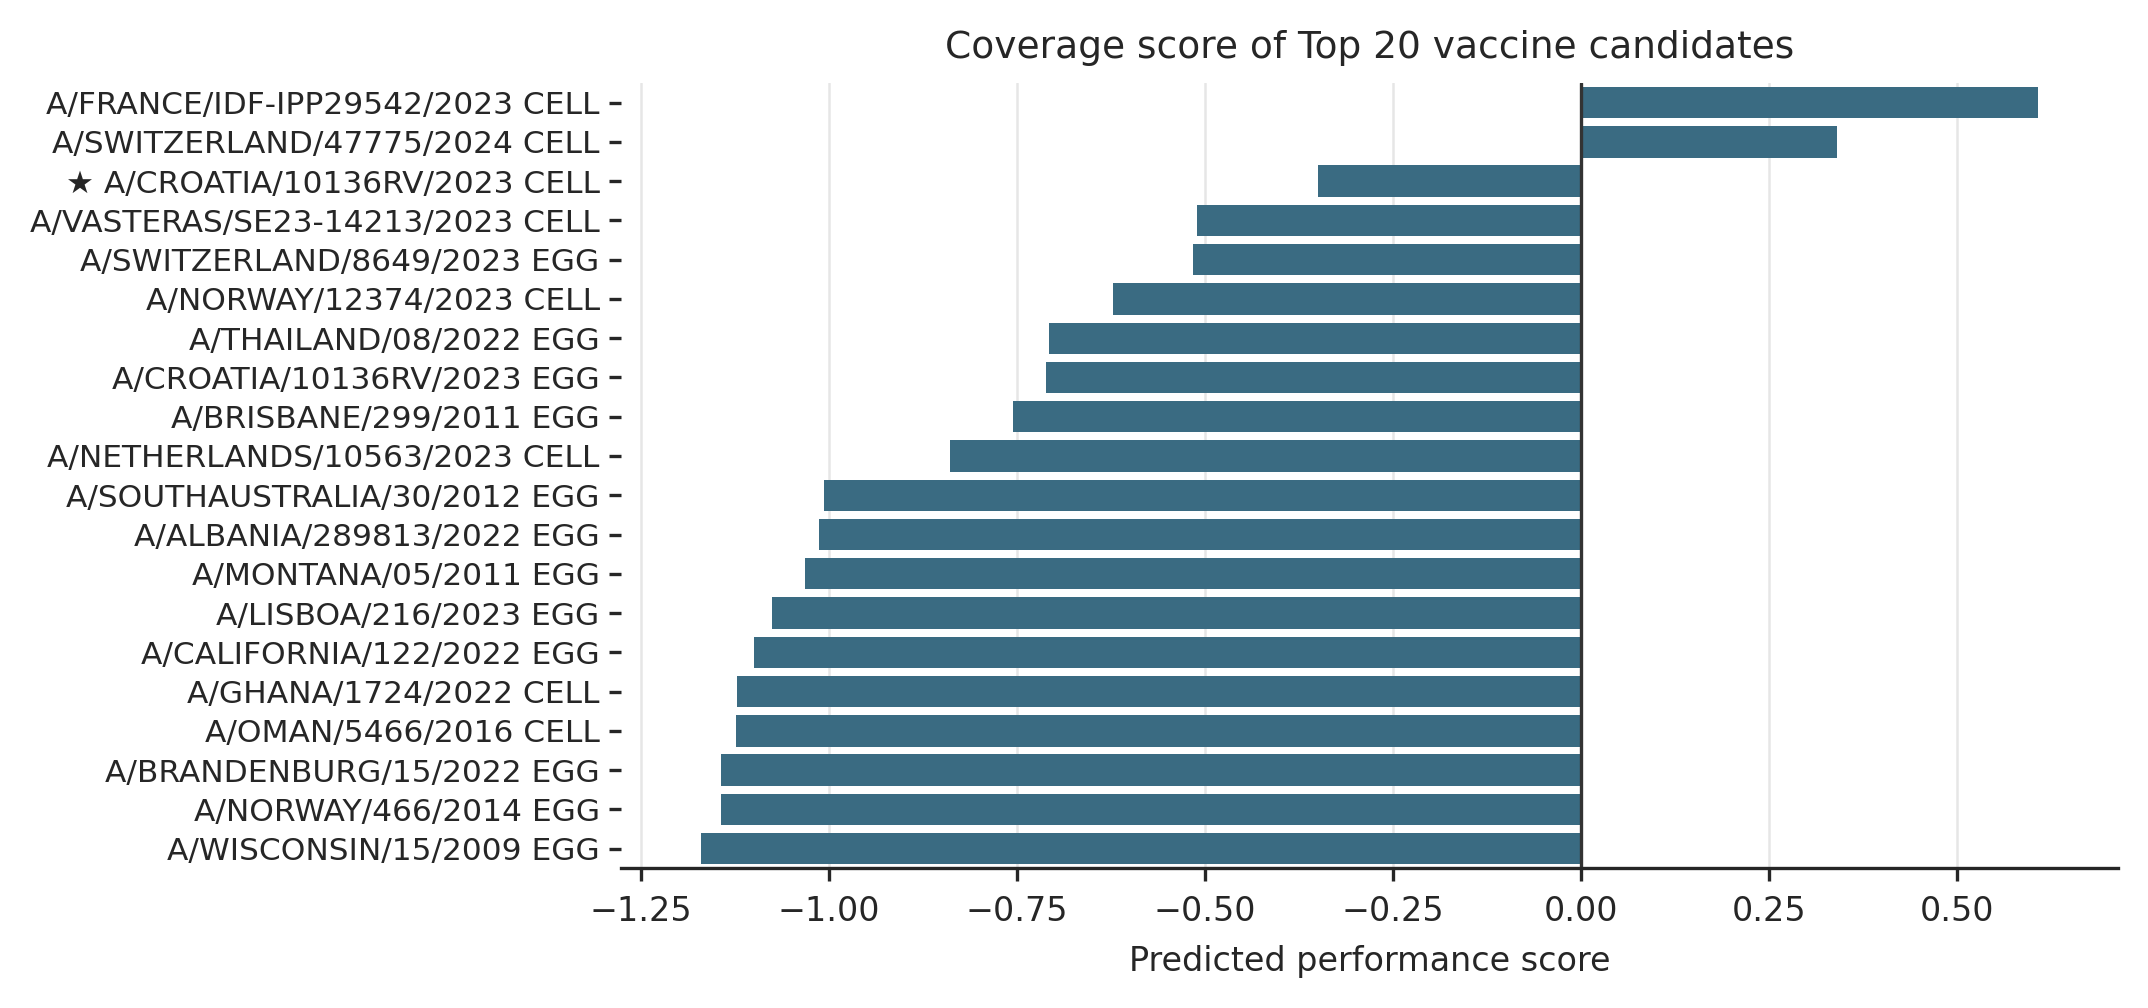

In [14]:
# 1) 全局风格：偏 Nature 的 paper 风格（克制、细线、无花哨）
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "figure.dpi": 300
})

# 2) 数据：按 prediction 排序后取 Top20（你原逻辑）
top20 = vaccine.sort_values("prediction", ascending=False) \
    .drop_duplicates(subset=["vaccine"], keep="first").head(20).copy()

# 精简标签
top20["vaccine_label"] = top20["vaccine"].str.replace(r"^A/","", regex=True) \
                                       .str.replace(" EGG"," (EGG)")\
                                       .str.replace(" CELL"," (CELL)")
ycol = "vaccine_label"
# ycol = "vaccine"

# 3) 画图：更紧凑的横向条形图 + 0 参考线 + 轻网格
fig, ax = plt.subplots(figsize=(7.2, 3.4))  # Nature 常用更紧凑比例；你也可微调

bar_color = "#2E6F8E"  # 低饱和蓝绿，比纯绿更“期刊”

sns.barplot(
    data=top20,
    y=ycol,
    x="prediction",
    color=bar_color,
    edgecolor="none",   # 取消边缘描边，避免脏
    ax=ax
)

# 0 参考线：你这个分布特别需要
ax.axvline(0, color="0.2", lw=0.8)

# 轻网格：只保留 x 方向，且非常淡
ax.xaxis.grid(True, which="major", color="0.9", lw=0.6)
ax.yaxis.grid(False)

# 去掉多余脊线：保留左/下或只保留下（按你偏好）
sns.despine(ax=ax, left=True, bottom=False)

ax.set_xlabel("Predicted performance score")
ax.set_ylabel("")
ax.set_title("Coverage score of Top 20 vaccine candidates", pad=6)

# 让 y 标签更整齐：减少与图形的“挤压”
ax.tick_params(axis="y", pad=2)

# 控制 x 轴范围（可选）：给正端留一点空白，避免贴边
xmin = top20["prediction"].min()
xmax = top20["prediction"].max()
pad = (xmax - xmin) * 0.06 if xmax > xmin else 0.1
ax.set_xlim(xmin - pad, xmax + pad)

who = "A/CROATIA/10136RV/2023 CELL"
labels = []
for name in top20["vaccine"]:
    labels.append(("★ " + name) if name in who else name)
ax.set_yticklabels(labels)

fig.tight_layout()
# plt.show()
plt.savefig('2026NH_vaccine.svg', transparent=True)